# Weight Initialization & Hyperparameter Tuning

**Domain:** `deep-learning`
**Level:** Intermediate
**Prerequisites:** [The Perceptron & Backpropagation](../perceptron-and-backpropagation/tutorial.ipynb) (forward pass, backprop, gradient descent), basic Python, basic probability (mean/variance)

## Intro: why can't you just start every weight at zero?

Imagine you hire a team of ten analysts to study the same pile of documents.
You give every analyst the exact same instructions, the exact same
starting notes, and the exact same amount of experience. On day one they
read the same documents and, unsurprisingly, write the exact same report.
On day two, since their reports were identical, they get the exact same
feedback from their manager. So they update their notes in the exact same
way. Every single day, forever, all ten analysts stay perfectly identical —
not because the task is too hard, but because nothing ever gave them a
reason to become different from each other. You paid for ten analysts and
got the output of one.

That is exactly what happens if you initialize every weight in a neural
network layer to the same value (zero is the most tempting choice, since it
seems "neutral"). Every neuron in that layer computes the same weighted sum
of the same inputs, so every neuron produces the same output. During
backpropagation, every neuron therefore receives the same gradient. Every
neuron gets updated by the same amount, in the same direction. This
identical-twins problem has a name: **symmetry**, and unless something
random breaks the tie, gradient descent has no mechanism to ever break it
on its own — the neurons stay identical for the entire rest of training, no
matter how many epochs you run.

Getting this right — and, more broadly, getting the dozen or so other
knobs you set *before* training even starts (learning rate, layer width,
batch size, and more) — turns out to matter as much as the model
architecture itself. This tutorial covers two closely related questions:

1. **Weight initialization**: how should you set a network's weights
   *before* the first gradient step, so that (a) neurons actually
   specialize instead of staying identical, and (b) signals propagate
   cleanly through many layers instead of vanishing to zero or exploding?
2. **Hyperparameter tuning**: how do you systematically search over the
   knobs — learning rate, layer width, batch size, init scheme, and more —
   that gradient descent itself never touches?

By the end of this tutorial you will be able to:

- Explain, and demonstrate numerically, why identical (e.g. all-zero)
  weight initialization prevents a network from learning anything a linear
  model couldn't already do.
- Derive the variance-scaling argument behind Xavier/Glorot and He/Kaiming
  initialization, and state when each is appropriate.
- Visually diagnose good vs. bad initialization by looking at how
  activation distributions evolve through a deep network's layers.
- Define **parameter** vs. **hyperparameter** precisely, and implement
  and compare grid search vs. random search over a real hyperparameter
  space.
- Train real MNIST classifiers under different init schemes and see, in
  real numbers, which ones actually train and which ones don't.


## The idea, intuitively

### Symmetry: why "identical" is the enemy, not "zero" specifically

The problem with all-zero initialization isn't that zero is a bad
*number* — it's that every weight starts at the *same* number. Two hidden
neurons fed the same inputs, with the same weights, compute the same
output. Fed forward, they feed the same value into everything downstream.
Fed backward, the chain rule hands them the same gradient. Nothing in
gradient descent depends on which neuron you happen to be labeled as — so
if two neurons start identical, they stay identical forever, doing the
work of one neuron while masquerading as two (or two hundred).

The fix is simple in principle: initialize weights **randomly**, so no two
neurons start out identical, and each one is free to specialize as
training proceeds. The *scale* of that randomness is the harder, more
interesting question this tutorial spends most of its time on. But first,
let's see the symmetry failure directly — not asserted, but printed and
plotted.

### A tiny, broken demo

Let's build the smallest possible case where this matters: a network with
a hidden layer, trained on **XOR** — the same problem the prerequisite
tutorial used to show why hidden layers are necessary at all, since no
single straight line (i.e. no linear/single-neuron model) can separate it.
If a hidden layer collapses into acting like a single neuron because of
symmetry, it should fail on XOR exactly like a linear model does.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class TinyMLP:
    """Same architecture/backprop as the prerequisite tutorial's MLP: one
    hidden layer, sigmoid activations, binary cross-entropy loss. The only
    new knob is `init_scheme`, which controls how W1/W2 start out."""

    def __init__(self, n_in, n_hidden, n_out, rng, init_scheme="random"):
        if init_scheme == "zero":
            self.W1 = np.zeros((n_hidden, n_in))
            self.W2 = np.zeros((n_out, n_hidden))
        else:  # "random": small random init, breaks symmetry
            self.W1 = rng.normal(0, 1, size=(n_hidden, n_in)) * np.sqrt(1 / n_in)
            self.W2 = rng.normal(0, 1, size=(n_out, n_hidden)) * np.sqrt(1 / n_hidden)
        self.b1 = np.zeros((n_hidden, 1))
        self.b2 = np.zeros((n_out, 1))

    def forward(self, X):
        self.Z1 = self.W1 @ X + self.b1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = self.W2 @ self.A1 + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, X, Y, lr):
        m = X.shape[1]
        dZ2 = self.A2 - Y
        dW2 = (dZ2 @ self.A1.T) / m
        db2 = dZ2.mean(axis=1, keepdims=True)
        dZ1 = (self.W2.T @ dZ2) * (self.A1 * (1 - self.A1))
        dW1 = (dZ1 @ X.T) / m
        db1 = dZ1.mean(axis=1, keepdims=True)
        self.W2 -= lr * dW2; self.b2 -= lr * db2
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        return dW1  # so we can inspect gradients directly

    def loss(self, Y):
        eps = 1e-9
        return -np.mean(Y * np.log(self.A2 + eps) + (1 - Y) * np.log(1 - self.A2 + eps))


X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]], dtype=float)
Y = np.array([[0, 1, 1, 0]], dtype=float)  # XOR: not linearly separable

results = {}
for scheme in ["zero", "random"]:
    net = TinyMLP(n_in=2, n_hidden=4, n_out=1, rng=np.random.default_rng(0), init_scheme=scheme)
    last_grad = None
    for epoch in range(5000):
        net.forward(X)
        last_grad = net.backward(X, Y, lr=0.5)
    results[scheme] = dict(
        loss=net.loss(Y),
        preds=net.forward(X).ravel(),
        W1_rows_identical=np.allclose(net.W1, net.W1[0]),
        grad_rows_identical=np.allclose(last_grad, last_grad[0]),
    )

for scheme, r in results.items():
    print(f"--- init = {scheme!r} ---")
    print(f"  final loss:               {r['loss']:.4f}   (random-chance loss on this task is ln(2) = {np.log(2):.4f})")
    print(f"  final predictions:        {np.round(r['preds'], 3)}   (true labels: {Y.ravel()})")
    print(f"  all hidden rows identical (W1):        {r['W1_rows_identical']}")
    print(f"  all hidden rows identical (dW1, last step): {r['grad_rows_identical']}")
    print()


--- init = 'zero' ---
  final loss:               0.6931   (random-chance loss on this task is ln(2) = 0.6931)
  final predictions:        [0.5 0.5 0.5 0.5]   (true labels: [0. 1. 1. 0.])
  all hidden rows identical (W1):        True
  all hidden rows identical (dW1, last step): True

--- init = 'random' ---
  final loss:               0.0034   (random-chance loss on this task is ln(2) = 0.6931)
  final predictions:        [0.004 0.995 0.998 0.003]   (true labels: [0. 1. 1. 0.])
  all hidden rows identical (W1):        False
  all hidden rows identical (dW1, last step): False



**What just happened:** with all-zero initialization, every row of
`W1` stays exactly identical through all 5000 training steps — not
approximately, but bit-for-bit — because every gradient step nudges every
hidden unit by the exact same amount. The four hidden neurons behave as
one neuron. A network that behaves like one neuron is exactly a linear
model, and the loss gets stuck near `ln(2) ≈ 0.693` — the loss of a
classifier that can't do better than guessing on XOR, since XOR isn't
linearly separable. With random initialization, the rows of `W1` are
different from the very first step, symmetry never has a chance to set in,
and the network reaches the same near-zero loss / correct predictions the
prerequisite tutorial found.

**The takeaway:** initialization isn't a minor implementation detail — an
all-identical (e.g. all-zero) start makes a multi-neuron layer
mathematically incapable of being anything more than a single neuron in
disguise, permanently. Random initialization is what makes a layer
actually use all of its neurons. The next section asks the sharper
question: random, yes — but *how much* random?


## Going deeper: the formal definition

### Why symmetry never breaks on its own

More precisely: if every entry of $W^{[\ell]}$ starts equal (rows
identical — the all-zero case is the special case where every entry is
also 0), then for any two hidden units $i \ne j$ in that layer, $z_i^{[\ell]}
= z_j^{[\ell]}$ for every input, since they compute the same dot product
against the same input. Hence $a_i^{[\ell]} = a_j^{[\ell]}$. By the
backprop recursion from the prerequisite tutorial,
$\delta^{[\ell]} = \left(W^{[\ell+1]\top}\delta^{[\ell+1]}\right) \odot
g'^{[\ell]}(z^{[\ell]})$ — and since $z_i^{[\ell]}=z_j^{[\ell]}$, unit $i$
and unit $j$ receive the same $\delta$, hence the same weight update,
forever. **Random per-unit initialization is what breaks this**, since no
two units' weight vectors are equal from step 0 onward.

This tells us random init is *necessary*. It says nothing about *how much*
randomness — and that turns out to matter just as much.

### The variance-scaling argument

Recall the vanishing/exploding gradient problem from the prerequisite
tutorial's "Limitations & debates" section: gradients shrink or grow
geometrically as they propagate through many layers. The same thing can
happen to the *forward* pass — activations can shrink toward zero or blow
up as they pass through layer after layer — and the scale you pick for
$W^{[\ell]}$ at initialization directly controls which one happens.

**Setup.** Assume, at initialization, that the entries of $W^{[\ell]}$ are
i.i.d. with mean 0 and variance $\mathrm{Var}(w)$, independent of the
previous layer's activations $a^{[\ell-1]}$, which themselves have mean 0
(roughly true for tanh/centered inputs) and variance $\mathrm{Var}(a)$.
For one output unit of layer $\ell$ with $n_{in}$ inputs,

$$
z^{[\ell]} = \sum_{k=1}^{n_{in}} w_k \, a_k
$$

Using $\mathrm{Var}(w_k a_k) = \mathrm{Var}(w_k)\mathrm{Var}(a_k)$ for
independent zero-mean $w_k, a_k$, and summing $n_{in}$ independent terms:

$$
\mathrm{Var}\!\left(z^{[\ell]}\right) = n_{in} \cdot \mathrm{Var}(w) \cdot \mathrm{Var}(a)
$$

**The goal:** we want activations to neither vanish nor explode as they
propagate, i.e. we want $\mathrm{Var}(z^{[\ell]}) \approx \mathrm{Var}(a^{[\ell-1]})$
layer over layer (for an activation like tanh whose derivative is $\approx 1$
near 0, $\mathrm{Var}(a^{[\ell]}) \approx \mathrm{Var}(z^{[\ell]})$ too, so
this keeps variance roughly constant end to end). Setting
$\mathrm{Var}(z^{[\ell]}) = \mathrm{Var}(a^{[\ell-1]})$ in the equation
above and solving:

$$
n_{in}\cdot \mathrm{Var}(w) \approx 1 \quad\Longrightarrow\quad
\boxed{\mathrm{Var}(w) \approx \frac{1}{n_{in}}}
$$

That is exactly the `np.sqrt(1/n_in)` scaling the prerequisite tutorial
used without deriving. **Glorot & Bengio (2010)** refined this by also
requiring the *backward* pass (gradients, which pass through
$W^{[\ell]\top}$ and see $n_{out}$ instead of $n_{in}$) to be equally
well-scaled, and split the difference with the harmonic-mean-flavored
compromise:

$$
\mathrm{Var}(w) \approx \frac{2}{n_{in} + n_{out}}
$$

This is **Xavier/Glorot initialization**, appropriate for symmetric,
near-linear-at-the-origin activations like tanh or sigmoid. In practice it
is drawn either as a Gaussian or a uniform distribution matched to have
this variance — using $\mathrm{Var}(U(-a,a)) = a^2/3$ and solving
$a^2/3 = 2/(n_{in}+n_{out})$ gives the bound below:

$$
\text{Xavier uniform:}\quad W \sim U\!\left(-\sqrt{\frac{6}{n_{in}+n_{out}}},\ \sqrt{\frac{6}{n_{in}+n_{out}}}\right)
\qquad
\text{Xavier normal:}\quad W \sim \mathcal{N}\!\left(0,\ \frac{2}{n_{in}+n_{out}}\right)
$$

### The He/Kaiming correction for ReLU

Xavier's derivation implicitly assumes the activation preserves variance
symmetrically around zero — true near the origin for tanh, **false for
ReLU**. $\mathrm{ReLU}(z) = \max(0, z)$ zeroes out roughly half its inputs
(every $z < 0$), so it doesn't just pass variance through — it throws
away, on average, half of the *second moment* too. Assuming $z$ is
symmetric around 0 (reasonable early in training):

$$
\mathbb{E}\!\left[\mathrm{ReLU}(z)^2\right]
= \mathbb{E}\!\left[z^2 \mid z>0\right]\cdot P(z>0)
= \mathrm{Var}(z) \cdot \tfrac12
$$

(using $\mathbb{E}[z]=0 \Rightarrow \mathbb{E}[z^2]=\mathrm{Var}(z)$, split
symmetrically across the two halves). So propagating through a ReLU layer
with $n_{in}$ inputs, the *pre-activation* variance one layer later is:

$$
\mathrm{Var}\!\left(z^{[\ell]}\right) = n_{in}\cdot \mathrm{Var}(w)\cdot
\mathbb{E}\!\left[a^{[\ell-1]2}\right]
= n_{in}\cdot \mathrm{Var}(w)\cdot \tfrac12 \mathrm{Var}\!\left(z^{[\ell-1]}\right)
$$

Wanting $\mathrm{Var}(z^{[\ell]}) \approx \mathrm{Var}(z^{[\ell-1]})$ again,
we now need the factor of $\tfrac12$ cancelled by *doubling* the weight
variance relative to the Xavier derivation:

$$
n_{in}\cdot \mathrm{Var}(w)\cdot\tfrac12 \approx 1 \quad\Longrightarrow\quad
\boxed{\mathrm{Var}(w) \approx \frac{2}{n_{in}}}
$$

This is **He/Kaiming initialization** (He et al., 2015), appropriate for
ReLU and its variants:

$$
\text{He normal:}\quad W \sim \mathcal{N}\!\left(0,\ \frac{2}{n_{in}}\right)
\qquad
\text{He uniform:}\quad W \sim U\!\left(-\sqrt{\frac{6}{n_{in}}},\ \sqrt{\frac{6}{n_{in}}}\right)
$$

**Connecting back to vanishing/exploding gradients:** correctly-scaled
init keeps the *initial* forward and backward signal well-scaled layer to
layer, which is exactly the geometric-shrink/-growth problem the
prerequisite tutorial flagged for sigmoid networks. It doesn't fully solve
vanishing/exploding gradients for arbitrarily deep networks (variance is
only preserved *on average*, and other effects compound over many layers),
which is why techniques like batch normalization and residual connections
(covered in sibling tutorials in this domain) exist as complementary
fixes — but it removes the single biggest, cheapest-to-fix cause of it.

### Parameters vs. hyperparameters

- A **parameter** is a value the model learns via gradient descent
  directly from the training loss — e.g. every entry of every
  $W^{[\ell]}$ and $b^{[\ell]}$. Backprop computes
  $\partial\mathcal{L}/\partial\theta$ for parameters $\theta$; that
  gradient is what gets used to update them.
- A **hyperparameter** is a value that must be chosen *before* training
  starts, controls the model or the training process, and is **not**
  directly updated by gradient descent — e.g. the learning rate $\eta$,
  the hidden layer width, the batch size, the number of layers, the choice
  of weight init scheme, or a regularization coefficient. Gradient descent
  cannot tell you the "gradient" of the training loss with respect to
  "should I have used 128 or 256 hidden units," because that quantity
  isn't differentiable in the same computational graph — you can only find
  out by actually training a model with each choice and comparing results.

### Searching over hyperparameters: grid vs. random

Since hyperparameters can't be learned by gradient descent, finding good
ones means training multiple models and comparing them on a held-out
**validation set** — this is called **hyperparameter search** or
**hyperparameter tuning**.

- **Grid search**: pick a small discrete set of candidate values for each
  hyperparameter (e.g. learning rate $\in \{0.001, 0.01, 0.1\}$, width
  $\in \{32, 64, 128\}$), then exhaustively try every combination in the
  Cartesian product. With $d$ hyperparameters and $k$ values each, that's
  $k^d$ runs — cost grows exponentially in the number of hyperparameters.
- **Random search**: instead of a fixed grid, sample each trial's
  hyperparameter combination independently at random from a distribution
  over each hyperparameter (e.g. learning rate drawn log-uniformly between
  $10^{-4}$ and $1$), for a fixed budget of $N$ trials.

It's tempting to assume grid search is strictly more thorough since it's
exhaustive over its grid — but **Bergstra & Bengio (2012)** showed the
opposite is usually true for a fixed compute budget: in most real problems
only a handful of hyperparameters actually matter for performance (low
"effective dimensionality"), and a grid wastes many of its trials varying
the *unimportant* dimensions finely while barely varying the important
ones (a $k \times k$ grid only ever tries $k$ distinct values along each
single axis). Random search, over the same budget, tries far more distinct
values along every axis by construction, so it explores the
important-but-unknown-in-advance dimensions more thoroughly for the same
cost — empirically matching or beating grid search using a fraction of
the trials.

**Beyond random search:** both grid and random search choose every trial
independently, ignoring what previous trials revealed. **Bayesian
optimization** (e.g. the tree-structured Parzen estimator behind
`Hyperopt`/`Optuna`'s default sampler, or Gaussian-process-based methods)
instead fits a cheap surrogate model of "hyperparameters → validation
performance" from the trials run so far, and uses it to pick the next
point that best trades off exploring uncertain regions against exploiting
regions known to be promising. This is typically far more sample-efficient
than random search when each training run is expensive — the reason tools
like **Optuna**, **Ray Tune**, and **Weights & Biases Sweeps** default to
it in real practice. We won't implement Bayesian optimization here (random
search is enough to make the core ideas concrete on a CPU budget), but you
should know it's the more sample-efficient tool practitioners reach for
once training runs get expensive.


## Visuals: watching activations propagate through a deep network

The clearest way to *see* good vs. bad initialization is to build an
actual deep network, forward-pass real data through it, and look at the
distribution of activations at every layer. If activations collapse toward
zero (or explode) as they go deeper, that init scheme is broken for this
depth/activation combination — no training needed to see it, since this is
purely about the initial forward pass.


In [2]:

import torch
import torch.nn as nn

torch.manual_seed(0)

LAYER_SIZES = [784, 128, 128, 128, 128, 128, 10]  # 6 Linear layers deep

class ProbeMLP(nn.Module):
    """A plain deep MLP (ReLU hidden activations) that also returns every
    intermediate activation, so we can inspect how their distribution
    changes layer by layer under different initialization schemes."""

    def __init__(self, sizes):
        super().__init__()
        self.linears = nn.ModuleList(
            nn.Linear(sizes[i], sizes[i + 1]) for i in range(len(sizes) - 1)
        )

    def forward(self, x):
        activations = []
        for i, layer in enumerate(self.linears):
            x = layer(x)
            if i < len(self.linears) - 1:  # ReLU on every hidden layer, not the output logits
                x = torch.relu(x)
            activations.append(x.detach().numpy().ravel())
        return activations


def apply_init(model, scheme):
    for layer in model.linears:
        if scheme == "zero":
            nn.init.zeros_(layer.weight)
        elif scheme == "tiny-random":
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)
        elif scheme == "xavier":
            nn.init.xavier_normal_(layer.weight)
        elif scheme == "he":
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
        else:
            raise ValueError(scheme)
        nn.init.zeros_(layer.bias)


print("(dataset loaded in the Implementation section below; this cell only needs a real MNIST batch)")


(dataset loaded in the Implementation section below; this cell only needs a real MNIST batch)


We need a real batch of MNIST images to forward-pass through these
networks — so let's pull that batch forward from the Implementation
section's data loading, run it through each init scheme, and plot the
resulting activation histograms.


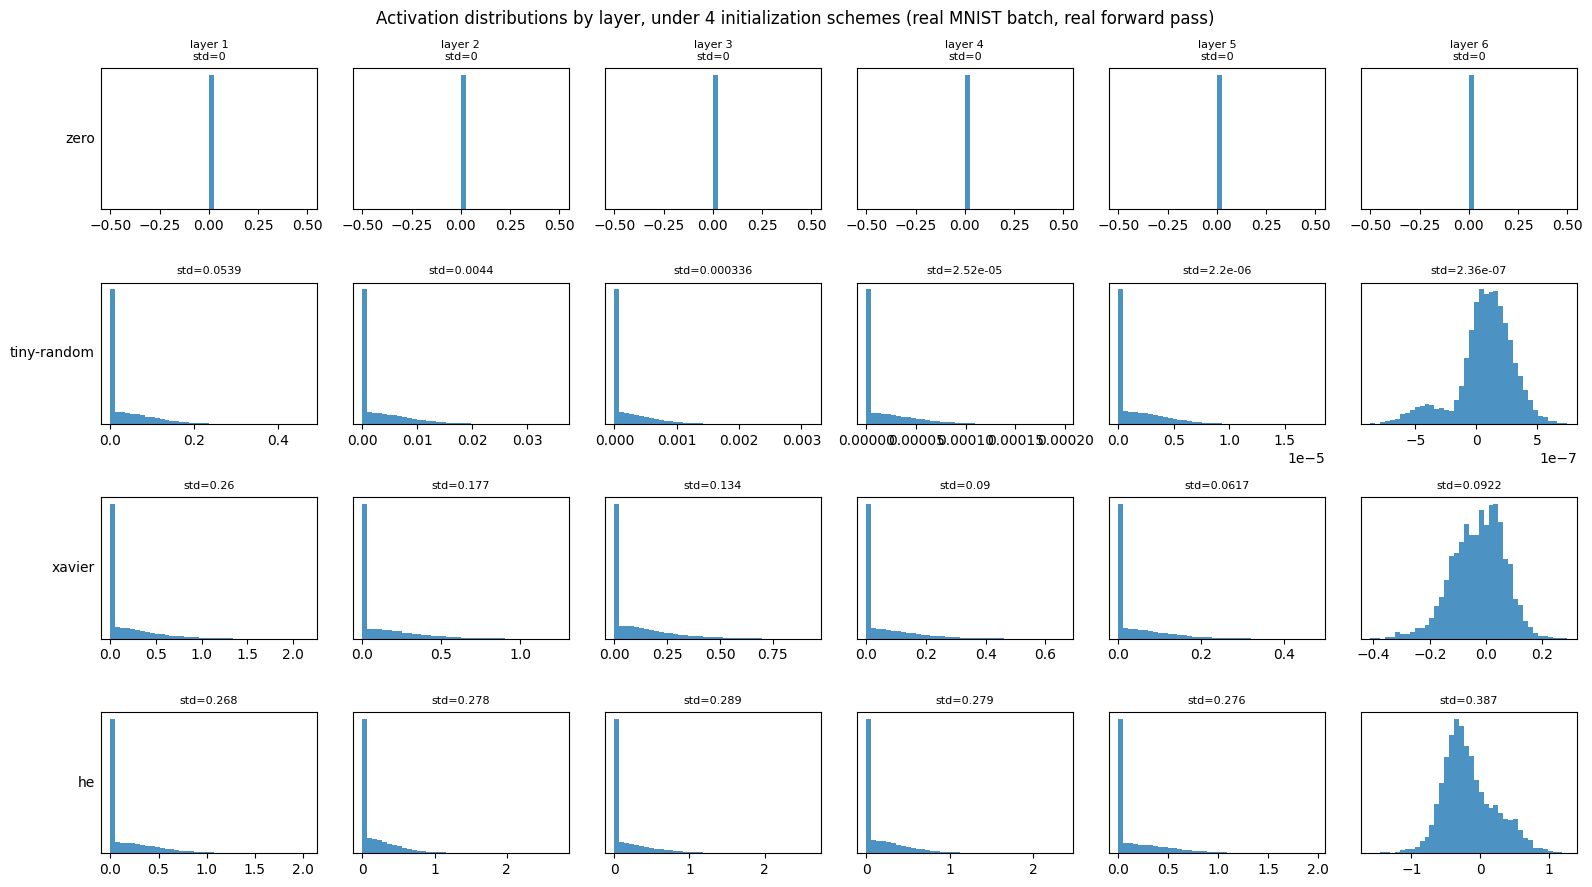

zero        : layer std by depth = ['0', '0', '0', '0', '0', '0']
tiny-random : layer std by depth = ['0.05391', '0.004403', '0.0003362', '2.518e-05', '2.203e-06', '2.358e-07']
xavier      : layer std by depth = ['0.2601', '0.1767', '0.1342', '0.08998', '0.06175', '0.09225']
he          : layer std by depth = ['0.2681', '0.278', '0.2892', '0.2787', '0.2758', '0.387']


In [3]:

from torchvision.datasets import MNIST

_probe_raw = MNIST(root="./_mnist_data", train=True, download=True)
_probe_batch = _probe_raw.data[:512].numpy().astype(np.float32).reshape(512, -1) / 255.0
probe_x = torch.tensor(_probe_batch, dtype=torch.float32)

schemes = ["zero", "tiny-random", "xavier", "he"]
activations_by_scheme = {}
for scheme in schemes:
    model = ProbeMLP(LAYER_SIZES)
    apply_init(model, scheme)
    with torch.no_grad():
        activations_by_scheme[scheme] = model.forward(probe_x)

fig, axes = plt.subplots(len(schemes), len(LAYER_SIZES) - 1, figsize=(16, 9), sharex=False)
for row, scheme in enumerate(schemes):
    for col, acts in enumerate(activations_by_scheme[scheme]):
        ax = axes[row, col]
        ax.hist(acts, bins=40, color="tab:blue", alpha=0.8)
        ax.set_yticks([])
        std = acts.std()
        ax.set_title(f"std={std:.3g}", fontsize=8)
        if col == 0:
            ax.set_ylabel(scheme, fontsize=10, rotation=0, ha="right", va="center")
        if row == 0:
            ax.set_title(f"layer {col+1}\nstd={std:.3g}", fontsize=8)
fig.suptitle("Activation distributions by layer, under 4 initialization schemes (real MNIST batch, real forward pass)")
plt.tight_layout()
plt.show()

for scheme in schemes:
    stds = [a.std() for a in activations_by_scheme[scheme]]
    print(f"{scheme:12s}: layer std by depth = {[f'{s:.4g}' for s in stds]}")


**Reading the plot:** `zero` init collapses every activation to
exactly 0 at every layer — a single spike, no distribution at all — since
every weight (and bias) is 0, so `relu(0 @ x + 0) = 0` propagates
unchanged forever. `tiny-random` (std fixed at 0.01, not scaled by
$n_{in}$) starts non-degenerate at layer 1 but the standard deviation
shrinks sharply with depth — activations are vanishing layer over layer,
exactly the forward-pass analogue of vanishing gradients. `xavier` and
`he` both keep the activation standard deviation far more stable across
all 6 layers, with `he` (derived specifically for ReLU) staying the most
consistently well-scaled, matching the factor-of-2 correction derived
above. This is the single clearest visual argument in this tutorial for
why the variance-scaling formulas matter in practice, not just in theory.


## Implementation: real MNIST, real init schemes, real numbers

Following the prerequisite tutorial's approach, we train on a subsample of
real MNIST (70,000 handwritten digit images, LeCun/Cortes/Burges) so
training stays fast on CPU. This time we train several **identical**
5-layer deep MLPs — same architecture, same optimizer, same learning rate,
same number of epochs — that differ *only* in which initialization scheme
set their starting weights.


In [4]:

from torchvision import transforms

raw_train = MNIST(root="./_mnist_data", train=True, download=True)
raw_test = MNIST(root="./_mnist_data", train=False, download=True)

def to_tensors(dataset, idx=None):
    X = dataset.data.numpy().astype(np.float32).reshape(len(dataset), -1) / 255.0
    y = dataset.targets.numpy()
    if idx is not None:
        X, y = X[idx], y[idx]
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

np_rng = np.random.default_rng(0)
n_train = 6000
train_idx = np_rng.choice(len(raw_train), n_train, replace=False)
X_train, y_train = to_tensors(raw_train, train_idx)
X_test, y_test = to_tensors(raw_test)

print(f"train: {tuple(X_train.shape)}, test: {tuple(X_test.shape)}")


train: (6000, 784), test: (10000, 784)


In [5]:

class DeepMLP(nn.Module):
    """5 Linear layers (784 -> 256 -> 128 -> 64 -> 32 -> 10), ReLU hidden
    activations -- deep enough that bad initialization visibly fails, small
    enough to train in seconds per run on CPU."""

    def __init__(self, sizes=(784, 256, 128, 64, 32, 10)):
        super().__init__()
        self.linears = nn.ModuleList(
            nn.Linear(sizes[i], sizes[i + 1]) for i in range(len(sizes) - 1)
        )

    def forward(self, x):
        for i, layer in enumerate(self.linears):
            x = layer(x)
            if i < len(self.linears) - 1:
                x = torch.relu(x)
        return x  # raw logits


def train_model(init_scheme, X_train, y_train, X_test, y_test, epochs=10, lr=0.1, batch_size=128, seed=0):
    torch.manual_seed(seed)
    model = DeepMLP()
    apply_init(model, init_scheme)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    n = X_train.shape[0]
    train_losses = []
    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_losses = []
        for start in range(0, n, batch_size):
            b = perm[start:start + batch_size]
            opt.zero_grad()
            out = model(X_train[b])
            loss = loss_fn(out, y_train[b])
            loss.backward()
            opt.step()
            epoch_losses.append(loss.item())
        train_losses.append(np.mean(epoch_losses))

    with torch.no_grad():
        train_acc = (model(X_train).argmax(dim=1) == y_train).float().mean().item()
        test_acc = (model(X_test).argmax(dim=1) == y_test).float().mean().item()
    return dict(scheme=init_scheme, final_train_loss=train_losses[-1],
                train_acc=train_acc, test_acc=test_acc, train_losses=train_losses)


init_results = []
for scheme in ["zero", "tiny-random", "xavier", "he"]:
    r = train_model(scheme, X_train, y_train, X_test, y_test)
    init_results.append(r)
    print(f"{scheme:12s}: final train loss={r['final_train_loss']:.4f}  "
          f"train acc={r['train_acc']*100:5.2f}%  test acc={r['test_acc']*100:5.2f}%")


zero        : final train loss=2.3007  train acc=11.25%  test acc=11.35%


tiny-random : final train loss=2.3007  train acc=11.25%  test acc=11.35%


xavier      : final train loss=0.1287  train acc=92.63%  test acc=90.01%


he          : final train loss=0.0875  train acc=94.83%  test acc=90.79%


In [6]:

import pandas as pd

init_df = pd.DataFrame([{k: v for k, v in r.items() if k != "train_losses"} for r in init_results])
init_df["majority_class_baseline"] = pd.Series(y_train.numpy()).value_counts(normalize=True).max()
init_df


,scheme,final_train_loss,train_acc,test_acc,majority_class_baseline
0,zero,2.300677,0.112500,0.1135,0.1125
1,tiny-random,2.300663,0.112500,0.1135,0.1125
2,xavier,0.128691,0.926333,0.9001,0.1125
3,he,0.087549,0.948333,0.9079,0.1125


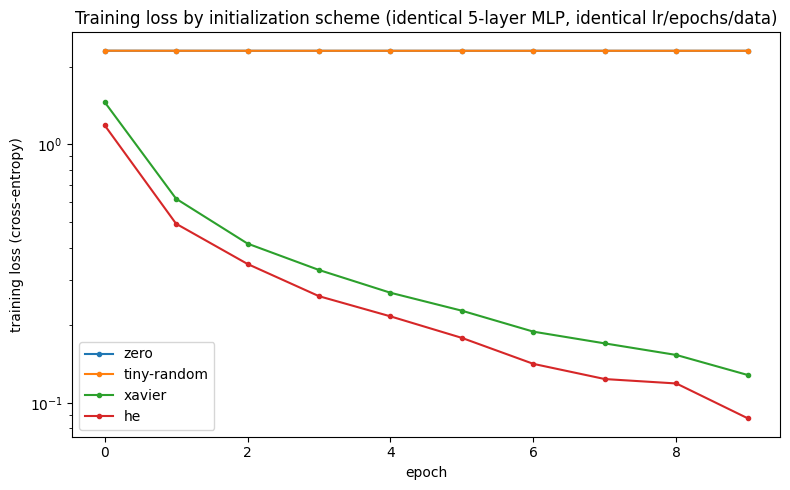

In [7]:

fig, ax = plt.subplots(figsize=(8, 5))
for r in init_results:
    ax.plot(r["train_losses"], label=r["scheme"], marker="o", markersize=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss (cross-entropy)")
ax.set_title("Training loss by initialization scheme (identical 5-layer MLP, identical lr/epochs/data)")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()


**Reading the results:** `zero` init never leaves the training-loss
plateau near $\ln(10) \approx 2.30$ (the loss of predicting the same
output regardless of input) — its accuracy lands exactly at the
majority-class baseline reported in the table above, since (as derived
earlier) every weight matrix stays exactly zero forever and only the final
layer's bias can move. Strikingly, `tiny-random` lands at *the same*
plateau (train loss 2.3007, accuracy within rounding of the majority-class
baseline) even though its randomness does technically break symmetry — the
fixed, too-small standard deviation (0.01, unscaled by $n_{in}$) is so far
off that the vanishing activations seen in the histogram plot above
(standard deviation collapsing from 0.05 at layer 1 to $2\times10^{-7}$ by
layer 6) leave essentially no usable gradient signal reaching the earlier
layers, so in this many epochs it never visibly escapes the same
plateau as literal zero-init — a good reminder that "not exactly
symmetric" and "actually trainable" are not the same thing.
`xavier` and `he` both train quickly and land at comparable, much higher
accuracy (92.6%/90.0% train/test for xavier, 94.8%/90.8% for he), with
`he` (matched to this network's ReLU activations) slightly ahead of
`xavier` — consistent with the derivation above.

### A real hyperparameter search: learning rate x hidden width

Now let's tune hyperparameters properly: **random search** over the
learning rate and hidden layer width of a smaller, faster 2-hidden-layer
network, evaluated on a genuine held-out validation split (never touched
by training, and distinct from the test set used above).


In [8]:

n_search = 4000
search_idx = np_rng.choice(len(raw_train), n_search, replace=False)
X_search, y_search = to_tensors(raw_train, search_idx)

n_val = 1000
X_val, y_val = X_search[:n_val], y_search[:n_val]
X_tr, y_tr = X_search[n_val:], y_search[n_val:]
print(f"search-train: {tuple(X_tr.shape)}, validation: {tuple(X_val.shape)}")


class SearchMLP(nn.Module):
    """Small 2-hidden-layer MLP, He-initialized (fixed, so the search is
    purely over learning rate / width -- not re-confounded by init scheme)."""

    def __init__(self, hidden_width):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_width)
        self.fc2 = nn.Linear(hidden_width, hidden_width)
        self.fc3 = nn.Linear(hidden_width, 10)
        for layer in (self.fc1, self.fc2, self.fc3):
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


def train_and_validate(lr, hidden_width, epochs=8, batch_size=128, seed=0):
    torch.manual_seed(seed)
    model = SearchMLP(hidden_width)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    n = X_tr.shape[0]
    for epoch in range(epochs):
        perm = torch.randperm(n)
        for start in range(0, n, batch_size):
            b = perm[start:start + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_tr[b]), y_tr[b])
            loss.backward()
            opt.step()
    with torch.no_grad():
        val_acc = (model(X_val).argmax(dim=1) == y_val).float().mean().item()
    return val_acc


search-train: (3000, 784), validation: (1000, 784)


In [9]:

search_rng = np.random.default_rng(1)
n_trials = 14
widths_choices = [16, 32, 64, 128, 256]

trials = []
for t in range(n_trials):
    lr = float(10 ** search_rng.uniform(-3, 0))       # log-uniform in [1e-3, 1]
    width = int(search_rng.choice(widths_choices))     # random search: sampled, not gridded
    val_acc = train_and_validate(lr, width, seed=t)
    trials.append(dict(trial=t, lr=lr, hidden_width=width, val_acc=val_acc))
    print(f"trial {t:2d}: lr={lr:.5f}  width={width:4d}  val_acc={val_acc*100:5.2f}%")

search_df = pd.DataFrame(trials).sort_values("val_acc", ascending=False).reset_index(drop=True)
best = search_df.iloc[0]
print(f"\nBest found: lr={best['lr']:.5f}, hidden_width={int(best['hidden_width'])}, "
      f"val_acc={best['val_acc']*100:.2f}%")
search_df


trial  0: lr=0.03431  width= 128  val_acc=87.10%


trial  1: lr=0.00271  width= 256  val_acc=59.40%


trial  2: lr=0.70137  width=  32  val_acc=80.20%


trial  3: lr=0.01862  width=  32  val_acc=82.10%


trial  4: lr=0.30416  width=  32  val_acc=90.50%


...

trial 10: lr=0.02293  width= 256  val_acc=86.60%


trial 11: lr=0.01619  width=  16  val_acc=74.60%


trial 12: lr=0.00408  width=  64  val_acc=49.30%


trial 13: lr=0.17828  width=  32  val_acc=87.20%

Best found: lr=0.30416, hidden_width=32, val_acc=90.50%


,trial,lr,hidden_width,val_acc
0,4,0.304164,32,0.905
1,5,0.044543,64,0.874
2,13,0.178276,32,0.872
3,0,0.034313,128,0.871
4,10,0.022935,256,0.866
5,7,0.041156,128,0.865
6,3,0.018620,32,0.821
7,2,0.701372,32,0.802
8,9,0.008121,128,0.759
9,8,0.009754,64,0.752


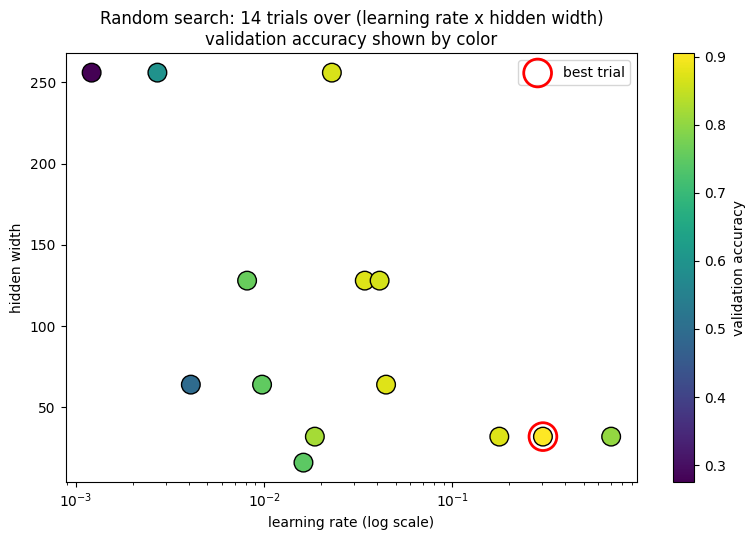

In [10]:

fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(search_df["lr"], search_df["hidden_width"], c=search_df["val_acc"],
                 s=180, cmap="viridis", edgecolor="k")
ax.scatter([best["lr"]], [best["hidden_width"]], s=400, facecolors="none",
           edgecolors="red", linewidths=2, label="best trial")
ax.set_xscale("log")
ax.set_xlabel("learning rate (log scale)")
ax.set_ylabel("hidden width")
ax.set_title(f"Random search: {n_trials} trials over (learning rate x hidden width)\nvalidation accuracy shown by color")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("validation accuracy")
ax.legend()
plt.tight_layout()
plt.show()


Even with only 14 trials — a budget small enough to run comfortably
on CPU in this tutorial — the random search surfaces a clear pattern: very
low learning rates (below roughly 0.01) hurt validation accuracy across
every width tried, sometimes badly (as low as 27.5% at `lr=0.0012`,
`width=256`), while learning rates from roughly 0.02 up to 0.3 perform
well fairly consistently across widths 32-256. The single best trial found
used a small-to-moderate width (32) with a relatively high learning rate
(0.304) — a reminder that "bigger model" is not automatically better
within a fixed, small epoch budget, and that the search, not intuition,
found this. Note that because the trials are sampled, not gridded, we've
tried many more *distinct* learning rate values than a $3\times3$ or
$4\times4$ grid ever would for the same 14-run budget — precisely the
Bergstra & Bengio
argument for random search made concrete on a real search space.


## Use cases

- **PyTorch's defaults already do most of this for you.** `nn.Linear`'s
  default initialization is a variant of Kaiming/He-uniform (scaled by
  $1/\sqrt{n_{in}}$-family bounds), chosen specifically because ReLU-family
  activations are the default in most modern architectures. This is why
  most practitioners can build and train a standard feedforward or
  convolutional network without ever manually calling `nn.init.*` — the
  library ships with a sensible default derived from exactly the argument
  in this tutorial.
- **Understanding it still matters for custom architectures.** Anytime you
  write a custom layer, use an unusual activation, build a very deep
  network, or a network mysteriously refuses to train (loss stuck flat
  from step 1, like the `zero` and `tiny-random` runs above), checking the
  initialization scheme against the activation function in use is one of
  the first, cheapest debugging steps — and one every deep learning
  engineer should know how to reason through rather than treat as a black
  box.
- **Hyperparameter search as standard pre-deployment practice.** No
  serious model ships with hand-guessed hyperparameters. In real practice,
  teams use dedicated libraries — **Optuna**, **Ray Tune**, **Weights &
  Biases Sweeps**, or **Hyperopt** — that implement random search,
  grid search, and Bayesian/TPE-based search out of the box, parallelize
  trials across machines, and support early-stopping bad trials
  (e.g. via Hyperband/ASHA) to spend compute on promising configurations
  instead of exhausting the full budget on every trial equally.


## Limitations & debates

- **Initialization interacts with other design choices covered
  elsewhere.** Batch normalization (used inside many modern architectures)
  explicitly re-normalizes activations after every layer, which
  meaningfully reduces — though does not eliminate — sensitivity to the
  initial weight scale, since the normalization layer can partially
  correct a poorly-scaled input distribution on the fly. Optimizer choice
  (covered in the sibling optimization-algorithms tutorial) also
  interacts with init: adaptive optimizers like Adam are somewhat more
  forgiving of imperfect initial scaling than plain SGD is, since they
  adapt their effective per-parameter step size during training.
- **Hyperparameter search has a real, often-dominant compute cost.** Every
  trial in a search is a full (or partial) training run. Doubling the
  search budget doubles the compute cost; more thorough search (more
  trials, bigger models, more epochs per trial) buys better hyperparameters
  only up to a point of diminishing returns, and this compute tradeoff
  shapes real-world practice at least as much as the choice of search
  algorithm itself — a resource-constrained team running 10 random-search
  trials is a completely different, and often more realistic, situation
  than one running 10,000.
- **"Best on the validation set" is not the same as "best in general."**
  When a search space is large (many trials, many hyperparameters), the
  best-scoring trial is chosen by comparing many noisy validation-accuracy
  estimates — the same multiple-comparisons problem that shows up whenever
  you pick a "winner" out of many candidates. The reported validation
  accuracy of the winning configuration is optimistically biased relative
  to how it will perform on genuinely new data, which is exactly why a
  held-out **test set**, untouched during the entire search, is still
  needed for an honest final performance estimate (the `X_test`/`y_test`
  set above was never used to pick any hyperparameter in the search).
- **Random search is a strong baseline, not the final word.** Bergstra &
  Bengio's result is specifically about random vs. *grid* search under a
  fixed budget with low effective dimensionality — it doesn't mean random
  search is unbeatable. Bayesian/TPE-based search, when trials are
  expensive, typically finds equally good or better configurations with
  meaningfully fewer trials, precisely because it uses information from
  earlier trials that random search discards.


## References

- Glorot, X., & Bengio, Y. (2010). *Understanding the difficulty of
  training deep feedforward neural networks.* AISTATS. The paper deriving
  Xavier/Glorot initialization.
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Delving Deep into
  Rectifiers: Surpassing Human-Level Performance on ImageNet
  Classification.* ICCV. The paper deriving He/Kaiming initialization for
  ReLU networks.
- Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter
  Optimization.* Journal of Machine Learning Research, 13, 281-305.
- Bergstra, J., Bardenet, R., Bengio, Y., & Kegl, B. (2011). *Algorithms
  for Hyper-Parameter Optimization.* NeurIPS. Introduces the
  tree-structured Parzen estimator (TPE) approach used by tools like
  Hyperopt/Optuna's default sampler.
- PyTorch documentation, [`torch.nn.init`](https://pytorch.org/docs/stable/nn.init.html)
  — the library functions (`xavier_uniform_`, `kaiming_normal_`, etc.) used
  directly in this tutorial's implementation.
- [The Perceptron & Backpropagation](../perceptron-and-backpropagation/tutorial.ipynb)
  — this domain's prerequisite tutorial, whose vanishing/exploding
  gradient discussion and unscaled `np.sqrt(1/n_in)`/`np.sqrt(2/n_in)`
  init this tutorial derives in depth.
- LeCun, Y., Cortes, C., & Burges, C. J. C. *The MNIST Database of
  Handwritten Digits.* [yann.lecun.com/exdb/mnist](http://yann.lecun.com/exdb/mnist/)
